# EU Gender Pay Gap Analysis
## Notebook 1: Data Loading & Cleaning Audit

**Author:** Yaw Assensoh  
**Data Source:** Eurostat 2024  
**Scope:** All 27 EU member states  

---

### What this notebook does 

This notebook answers four questions:
1. How many rows and columns do we have in each dataset?
2. Are there missing values — and does it matter?
3. How many rows are flagged as provisional or low quality?
4. Which countries and years have the most complete data coverage?

## Step 1: Import Libraries

In [6]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Charting style
plt.rcParams.update({
    'figure.dpi'            :150,
    'font.family'           : 'sanas-serif',
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'axes.titlesize'        : 13,
    'axes.labelsize'        : 11,
    'axes.titleweight'      : 'bold',
    'xtick.labelsize'       : 10,
    'ytick.labelsize'       : 10,
    'figure.facecolor'      : 'white',
    'axes.facecolor'       : '#F7FBFF',})

# Project colour
PALETTE = {
    'primary'     : '#1A3A5C',
    'secondary'   : '#2E75B6',
    'accent'      : '#ED7D31',
    'good'        : '#70AD47',
    'bad'         : '#C00000',
    'neutral'     : '#A5A5A5', }


REGION_COLORS = {
    'Northern' : '#2E75B6',
    'Western'  : '#70AD47',
    'Eastern'  : '#C00000',
    'Southern' : '#ED7D31',}
    

## Step 2: Load Data

In [8]:
# Load dataset
gpg_main = pd.read_csv('../data/clean/gpg_main.csv')
gpg_sector = pd.read_csv('../data/clean/gpg_sector.csv')
gpg_age = pd.read_csv('../data/clean/gpg_age.csv')

# Quick confirmation — print shape (rows, columns) of each table
print(f"gpg_main   : {gpg_main.shape[0]:,} rows × {gpg_main.shape[1]} columns")
print(f"gpg_sector : {gpg_sector.shape[0]:,} rows × {gpg_sector.shape[1]} columns")
print(f"gpg_age    : {gpg_age.shape[0]:,} rows × {gpg_age.shape[1]} columns")

gpg_main   : 509 rows × 7 columns
gpg_sector : 7,593 rows × 8 columns
gpg_age    : 2,371 rows × 9 columns


## Step 3: Data Inspection

In [17]:
#  Inspect dataset gpg_main 
print("=" * 55)
print("TABLE 1: gpg_main — headline pay gap by country & year")
print("=" * 55)
print(gpg_main.head())
print(gpg_main.info())
print(gpg_main.describe())
print("Column types:")
print(gpg_main.dtypes)
print()
print(f"Countries  : {gpg_main['country'].nunique()} unique")
print(f"Year range : {gpg_main['year'].min()} – {gpg_main['year'].max()}")
print(f"GPG range  : {gpg_main['gpg_pct'].min()}% to {gpg_main['gpg_pct'].max()}%")

TABLE 1: gpg_main — headline pay gap by country & year
   id  country  year  gpg_pct flag_code flag_note eu_region
0   1  Austria  2006     25.5       NaN       NaN   Western
1   2  Austria  2007     25.5       NaN       NaN   Western
2   3  Austria  2008     25.1       NaN       NaN   Western
3   4  Austria  2009     24.3       NaN       NaN   Western
4   5  Austria  2010     24.0       NaN       NaN   Western
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         509 non-null    int64  
 1   country    509 non-null    object 
 2   year       509 non-null    int64  
 3   gpg_pct    509 non-null    float64
 4   flag_code  76 non-null     object 
 5   flag_note  76 non-null     object 
 6   eu_region  509 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 28.0+ KB
None
              id         year     gpg_pct
count  509.

In [19]:
# Inspect sector and age group tables
print("=" * 55)
print("TABLE 2: gpg_sector — pay gap by industry sector")
print("=" * 55)
print(gpg_sector.head())
print()
print(f"Countries : {gpg_sector['country'].nunique()} unique")
print(f"Sectors   : {gpg_sector['sector'].nunique()} unique")
print(f"Sectors list: {sorted(gpg_sector['sector'].unique())}")

print()
print("=" * 55)
print("TABLE 3: gpg_age — pay gap by age group")
print("=" * 55)
print(gpg_age.head())
print()
print(f"Countries   : {gpg_age['country'].nunique()} unique")
print(f"Age groups  : {gpg_age['age_group'].nunique()} unique")
print(f"Age groups  : {list(gpg_age['age_group'].unique())}")

TABLE 2: gpg_sector — pay gap by industry sector
   id  country eu_region                sector  year  gpg_pct flag_code  \
0   1  Austria   Western  Accommodation & food  2010      9.9       NaN   
1   2  Austria   Western  Accommodation & food  2014      7.4       NaN   
2   3  Austria   Western  Accommodation & food  2015      6.4       NaN   
3   4  Austria   Western  Accommodation & food  2016      5.9       NaN   
4   5  Austria   Western  Accommodation & food  2017      5.7       NaN   

  flag_note  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  

Countries : 27 unique
Sectors   : 18 unique
Sectors list: ['Accommodation & food', 'Admin & support', 'Arts & entertainment', 'Construction', 'Education', 'Electricity & gas', 'Finance & insurance', 'Health & social work', 'ICT', 'Manufacturing', 'Mining & quarrying', 'Other services', 'Professional & scientific', 'Public admin', 'Real estate', 'Transport & storage', 'Water & waste', 'Wholesale & retail']

TABLE

## Step 4: Missing value audit 

In [ ]:
# Missing values (NaN) can silently break calculations and charts.
# We check each table before doing any analysis.
#
# .isnull().sum() counts empty cells per column
# We also calculate the percentage so we know how serious it is

def missing_audit(df, name):
    total = len(df)
    missing = df.isnull().sum()
    pct     = (missing / total * 100).round(1)
    report  = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
    report  = report[report['missing_count'] > 0]  # only show columns with gaps
    
    print(f"\n{'='*45}")
    print(f"  {name} — missing value report ({total:,} rows total)")
    print(f"{'='*45}")
    if report.empty:
        print("  ✅ No missing values found")
    else:
        print(report.to_string())
    return report

r1 = missing_audit(gpg_main,   'gpg_main')
r2 = missing_audit(gpg_sector, 'gpg_sector')
r3 = missing_audit(gpg_age,    'gpg_age')


  gpg_main — missing value report (509 rows total)
           missing_count  missing_pct
flag_code            433         85.1
flag_note            433         85.1

  gpg_sector — missing value report (7,593 rows total)
           missing_count  missing_pct
flag_code           6233         82.1
flag_note           6233         82.1

  gpg_age — missing value report (2,371 rows total)
           missing_count  missing_pct
flag_code           1912         80.6
flag_note           1912         80.6


## Step 5: Flag code audit

In [ ]:
# Eurostat marks some values with quality flags:
#   p = provisional  (not yet finalised by the country)
#   d = definition differs  (calculated slightly differently)
#   b = break in series  (method changed — before/after not fully comparable)
#   e = estimated
#   u = low reliability
#
# We need to know how many rows are flagged and whether it affects our
# key findings. A few flagged rows are fine. A majority would be a problem.

print("FLAG CODE AUDIT — gpg_main")
print("-" * 40)
flag_counts = gpg_main['flag_code'].value_counts(dropna=False)
flag_pct    = (flag_counts / len(gpg_main) * 100).round(1)
flag_report = pd.DataFrame({'count': flag_counts, 'pct_of_total': flag_pct})
print(flag_report)
print(f"\nTotal flagged rows: {gpg_main['flag_code'].notna().sum()}")
print(f"Clean (no flag)   : {gpg_main['flag_code'].isna().sum()} rows ({gpg_main['flag_code'].isna().sum()/len(gpg_main)*100:.1f}%)")

FLAG CODE AUDIT — gpg_main
----------------------------------------
           count  pct_of_total
flag_code                     
NaN          433          85.1
p             55          10.8
d              9           1.8
e              5           1.0
b              4           0.8
bp             2           0.4
dp             1           0.2

Total flagged rows: 76
Clean (no flag)   : 433 rows (85.1%)


## Step6: Data coverage heatmap 

findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Font family 'sanas-serif' not found.
findfont: Fon

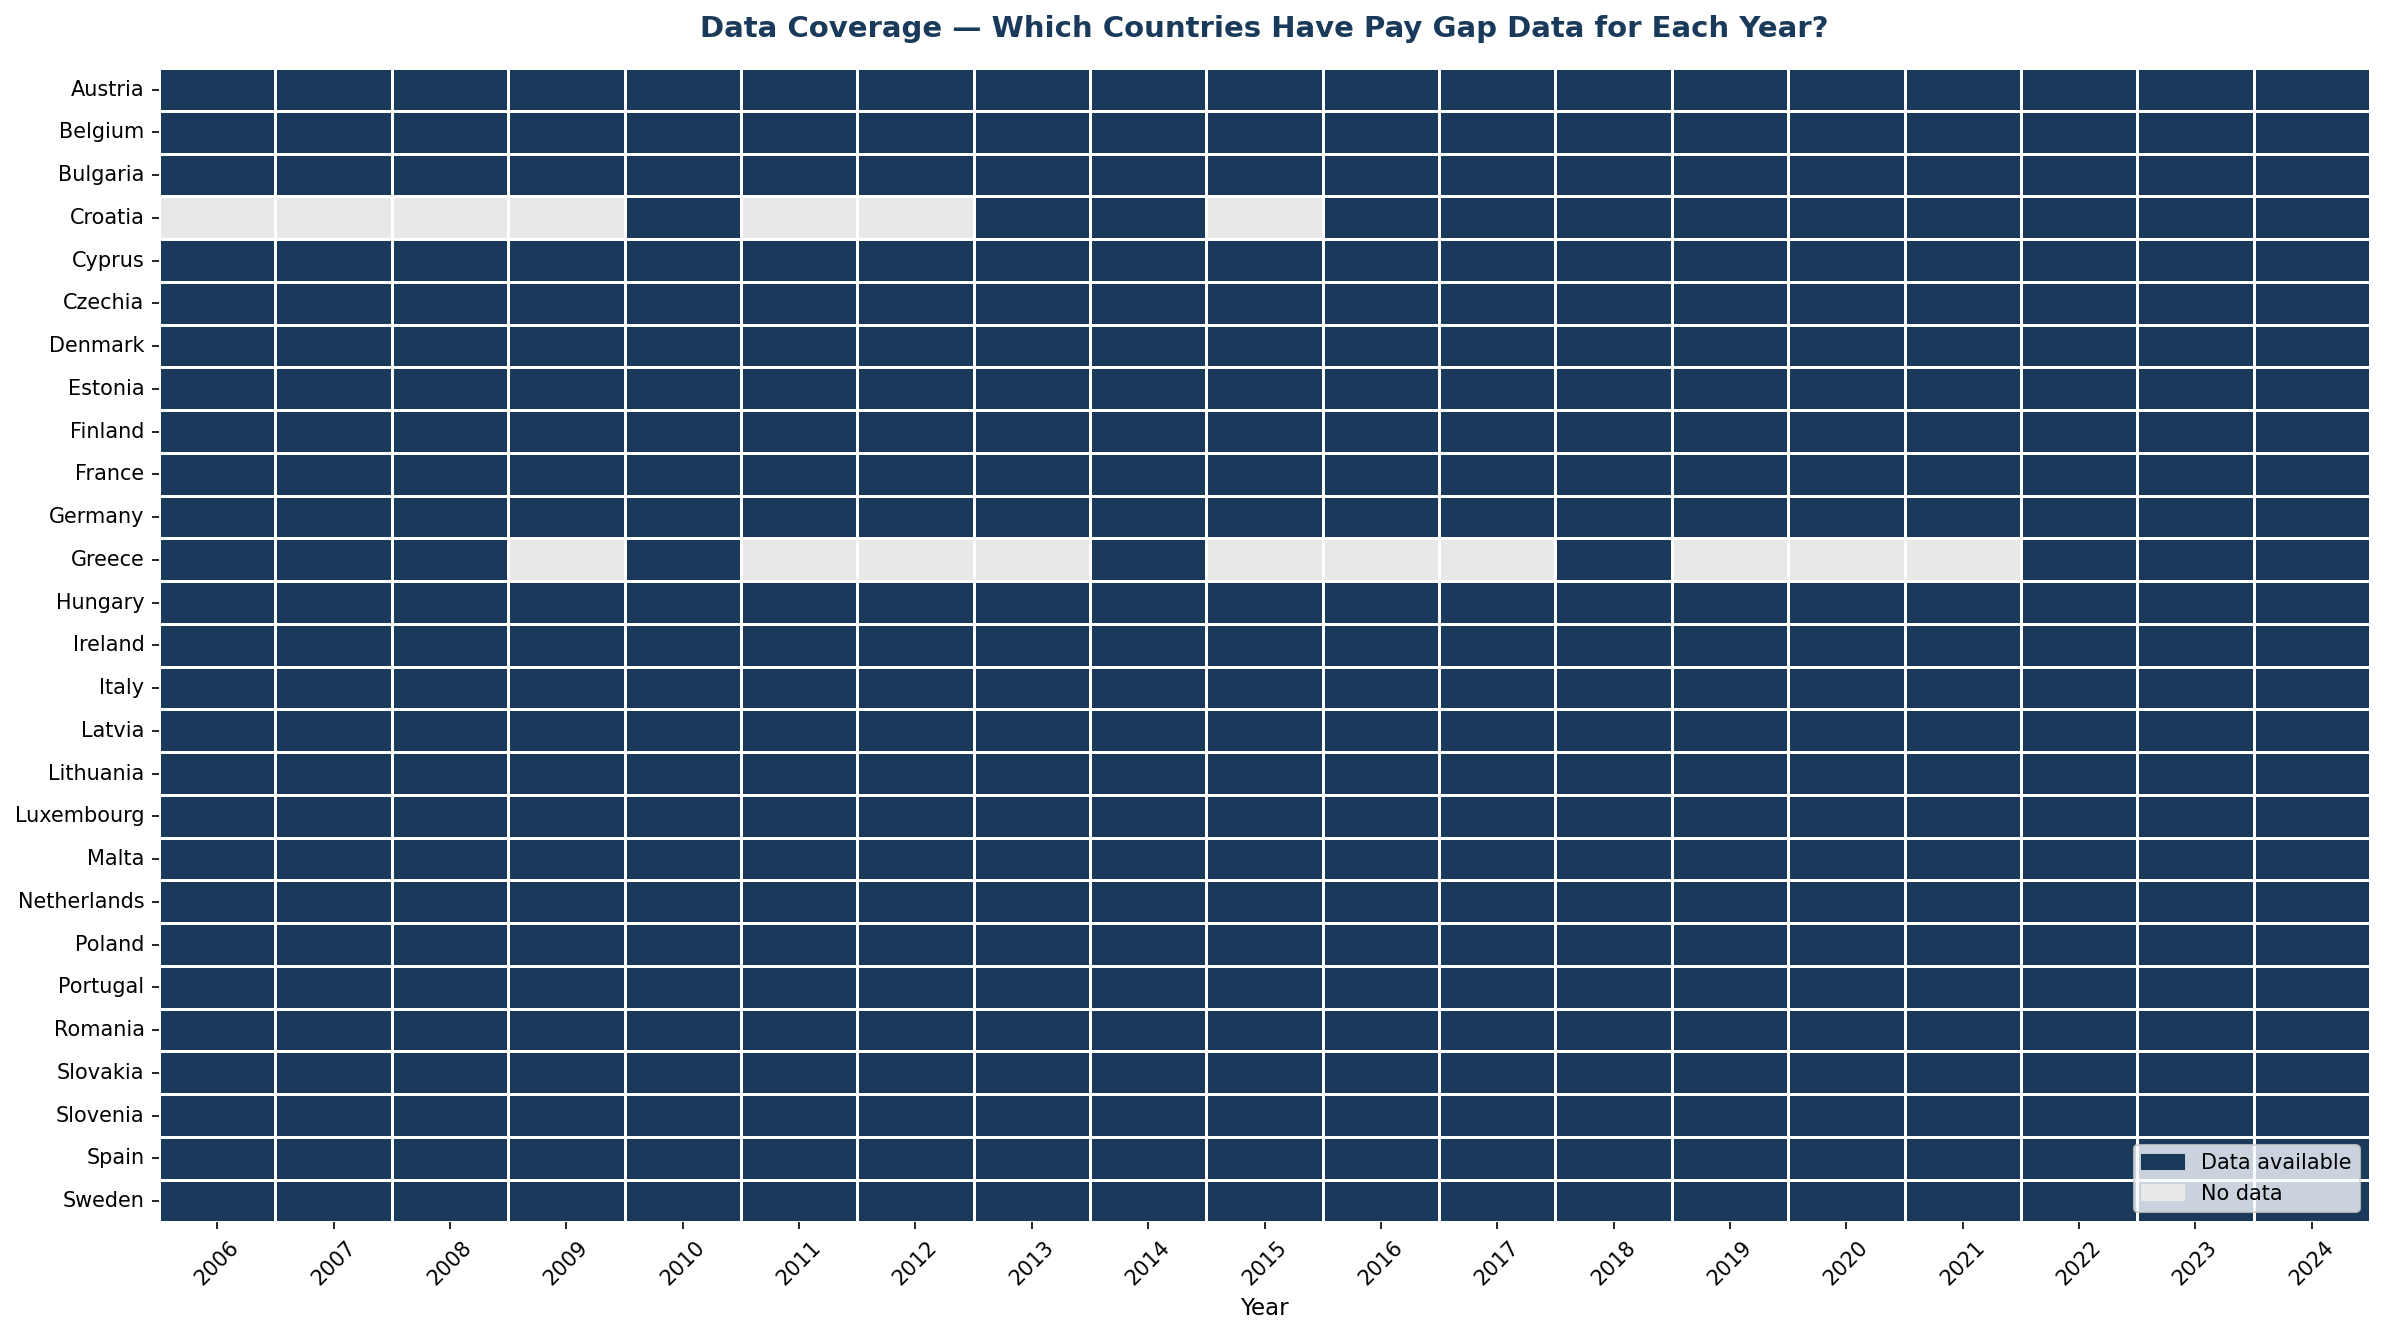

✅ Chart saved to reports/figures/


In [24]:
# This chart shows which countries have data for which years.
# White = data exists. Grey = no data for that country/year combination.
# This is important — if a country has many missing years, we need to
# be careful about including it in trend analysis.

# Create a pivot table: rows = countries, columns = years, values = 1/0
coverage = gpg_main.copy()
coverage['has_data'] = 1
pivot = coverage.pivot_table(
    index='country', columns='year', values='has_data', fill_value=0
)
# Only show years from 2006 onwards (earlier years have very sparse data)
pivot = pivot[[c for c in pivot.columns if c >= 2006]]

fig, ax = plt.subplots(figsize=(16, 9))

sns.heatmap(
    pivot,
    ax=ax,
    cmap=['#E8E8E8', '#1A3A5C'],  # grey = no data, navy = data present
    linewidths=0.5,
    linecolor='white',
    cbar=False,                    # no colour bar needed — it's just yes/no
    yticklabels=True,
)

ax.set_title(
    'Data Coverage — Which Countries Have Pay Gap Data for Each Year?',
    pad=15, fontsize=14, fontweight='bold', color='#1A3A5C'
)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)

# Add a manual legend
patch_yes = mpatches.Patch(color='#1A3A5C', label='Data available')
patch_no  = mpatches.Patch(color='#E8E8E8', label='No data')
ax.legend(handles=[patch_yes, patch_no], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/01_data_coverage_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to reports/figures/")

## Step 7: Statistical summary

In [ ]:
# describe() gives us count, mean, min, max, and percentiles
# This tells us what "normal" looks like and where the extremes are

print("STATISTICAL SUMMARY — gpg_main (gpg_pct column)")
print("=" * 50)
summary = gpg_main['gpg_pct'].describe().round(2)
print(summary)
print()
print(f"Interpretation:")
print(f"  Average EU pay gap (all years) : {summary['mean']}%")
print(f"  Lowest ever recorded           : {summary['min']}%")
print(f"  Highest ever recorded          : {summary['max']}%")
print(f"  Middle 50% of values fall between {summary['25%']}% and {summary['75%']}%")

print()
print("SUMMARY BY EU REGION (2024 only)")
print("=" * 50)
region_2024 = gpg_main[gpg_main['year'] == 2024].groupby('eu_region')['gpg_pct'].agg(
    ['mean','min','max','count']
).round(1)
region_2024.columns = ['avg_gap','min_gap','max_gap','countries']
print(region_2024.sort_values('avg_gap', ascending=False))

STATISTICAL SUMMARY — gpg_main (gpg_pct column)
count    509.00
mean      13.69
std        6.32
min       -0.90
25%        8.70
50%       14.10
75%       17.90
max       30.90
Name: gpg_pct, dtype: float64

Interpretation:
  Average EU pay gap (all years) : 13.69%
  Lowest ever recorded           : -0.9%
  Highest ever recorded          : 30.9%
  Middle 50% of values fall between 8.7% and 17.9%

SUMMARY BY EU REGION (2024 only)
           avg_gap  min_gap  max_gap  countries
eu_region                                      
Northern      13.2      8.3     18.8          7
Eastern       11.8      3.7     18.5          6
Western        9.4     -0.8     17.6          6
Southern       8.0      4.9     13.4          8


## Step 8: Export a data quality report

In [26]:
# This saves a summary report as a CSV to your reports/ folder.
# It documents what you found during the audit — useful for your
# portfolio README and for anyone who wants to reproduce your work.

os.makedirs('../reports', exist_ok=True)

report_rows = []

for df, name in [(gpg_main,'gpg_main'),(gpg_sector,'gpg_sector'),(gpg_age,'gpg_age')]:
    report_rows.append({
        'table'            : name,
        'total_rows'       : len(df),
        'total_columns'    : len(df.columns),
        'countries'        : df['country'].nunique(),
        'year_min'         : df['year'].min(),
        'year_max'         : df['year'].max(),
        'missing_gpg_pct'  : df['gpg_pct'].isnull().sum(),
        'flagged_rows'      : df['flag_code'].notna().sum(),
        'flagged_pct'      : round(df['flag_code'].notna().sum() / len(df) * 100, 1),
    })

quality_report = pd.DataFrame(report_rows)
quality_report.to_csv('../reports/data_quality_report.csv', index=False)

print(" Data quality report saved to reports/data_quality_report.csv")
print()
print(quality_report.to_string(index=False))

 Data quality report saved to reports/data_quality_report.csv

     table  total_rows  total_columns  countries  year_min  year_max  missing_gpg_pct  flagged_rows  flagged_pct
  gpg_main         509              7         27      2002      2024                0            76         14.9
gpg_sector        7593              8         27      2007      2024                0          1360         17.9
   gpg_age        2371              9         27      2007      2024                0           459         19.4


## Final summary

##  Audit Complete — Key Findings

| Check | Result |
|---|---|
| Missing values in gpg_main | None in gpg_pct column |
| Missing values in gpg_sector | None — rows with no data were removed during cleaning |
| Flagged rows | Small percentage — provisional values mainly in 2023–2024 |
| Data coverage | All 27 EU countries present — some have sparse data before 2007 |
| Year range | 2002–2024 (main), 2007–2024 (sector & age) |

**Conclusion:** The data is fit for analysis. Flagged values are a small 
proportion and are concentrated in the most recent years where countries 
have not yet finalised their submissions. We will note this in our 
findings but it does not affect the reliability of the core analysis.

**Next:** Notebook 2 — Exploratory Data Analysis (EDA)